# NB05 — The Shift: Confirmatory Analysis
**Signal/Pulse · Market Analysis**

**Hypothesis:** Basic, honest skincare has structurally overtaken cosmetics/makeup
in Japanese consumer priority post-COVID.

**This notebook tests that hypothesis across three independent data sources:**
- @cosme + Amazon JP review corpus (consumer voice — Sections 1 & 2)
- Google Trends Block A (search demand — Sections 3 & 4)
- Rakuten Ichiba product catalog (commercial supply — Section 5)

YouTube corroborates in the dashboard (NB06 Section 6) but is not re-analysed here.

**Public notebook — brand-agnostic market analysis.**
Company-specific lens analysis in NB05a/b (private, gitignored).

**Canonical tier throughout:** `COALESCE(p.tier_predicted, p.tier_override, c.tier)`
This applies NB02b classifier predictions and NB02 keyword overrides before
falling back to Rakuten's original category assignment.


## 0. Setup

In [1]:
import sys
sys.path.insert(0, "..")

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from src.schema import get_connection
from src.config import PROJECT
from src.viz import PALETTE, fig_ax, tight, annotate_covid, apply_style

apply_style()

# Tier colours — defined once, used across all cells in this notebook
C_SKIN = '#1565C0'  # steel blue
C_COSM = '#D81B60'  # deep rose

conn = get_connection()

for tbl in ['reviews', 'products', 'trends_weekly', 'yt_comments']:
    n = conn.execute(f'SELECT COUNT(*) FROM {tbl}').fetchone()[0]
    print(f'  {tbl:<20}: {n:>8,} rows')


Font: Yu Gothic ✓
  reviews             :   22,451 rows
  products            :   32,797 rows
  trends_weekly       :    4,635 rows
  yt_comments         :   60,676 rows


## 1. The Core Shift — Review Volume by Tier 2019–2025

The central question: is skincare's share of beauty reviews structurally higher
post-COVID than before?

**SQL pattern:** Two CTEs — `yearly_tier` aggregates by tier and year,
`total_yearly` sums across all tiers for share calculation.
`ROUND(100.0 * ... / NULLIF(..., 0), 1)` computes share safely.


In [2]:
sql_shift = '''
WITH yearly_tier AS (
    SELECT
        r.review_year,
        COALESCE(p.tier_predicted, p.tier_override, c.tier) AS tier,
        COUNT(*) AS review_count
    FROM reviews r
    JOIN products p   ON r.product_id  = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    WHERE r.review_year BETWEEN 2019 AND 2025
      AND COALESCE(p.tier_predicted, p.tier_override, c.tier)
          IN ('skincare', 'cosmetics')
    GROUP BY r.review_year,
             COALESCE(p.tier_predicted, p.tier_override, c.tier)
),
total_yearly AS (
    SELECT
        review_year,
        SUM(review_count) AS total_count
    FROM yearly_tier
    GROUP BY review_year
)
SELECT
    yt.review_year,
    yt.tier,
    yt.review_count,
    ty.total_count,
    ROUND(100.0 * yt.review_count / NULLIF(ty.total_count, 0), 1) AS share_pct
FROM yearly_tier yt
JOIN total_yearly ty ON yt.review_year = ty.review_year
ORDER BY yt.review_year, yt.tier
'''

df_shift = pd.read_sql(sql_shift, conn)
print('Review volume by tier — 2019 to 2025:')
print(df_shift.to_string(index=False))

df_pivot = df_shift.pivot(
    index='review_year', columns='tier',
    values=['review_count', 'share_pct']
)
df_pivot.columns = ['_'.join(col) for col in df_pivot.columns]
print()
print('Pivoted view:')
print(df_pivot.to_string())


Review volume by tier — 2019 to 2025:
 review_year      tier  review_count  total_count  share_pct
        2019 cosmetics            24          168       14.3
        2019  skincare           144          168       85.7
        2020 cosmetics            48          411       11.7
        2020  skincare           363          411       88.3
        2021 cosmetics           122          769       15.9
        2021  skincare           647          769       84.1
        2022 cosmetics           304          955       31.8
        2022  skincare           651          955       68.2
        2023 cosmetics           526         1584       33.2
        2023  skincare          1058         1584       66.8
        2024 cosmetics           738         3093       23.9
        2024  skincare          2355         3093       76.1
        2025 cosmetics          1069         8392       12.7
        2025  skincare          7323         8392       87.3

Pivoted view:
             review_count_cosmet

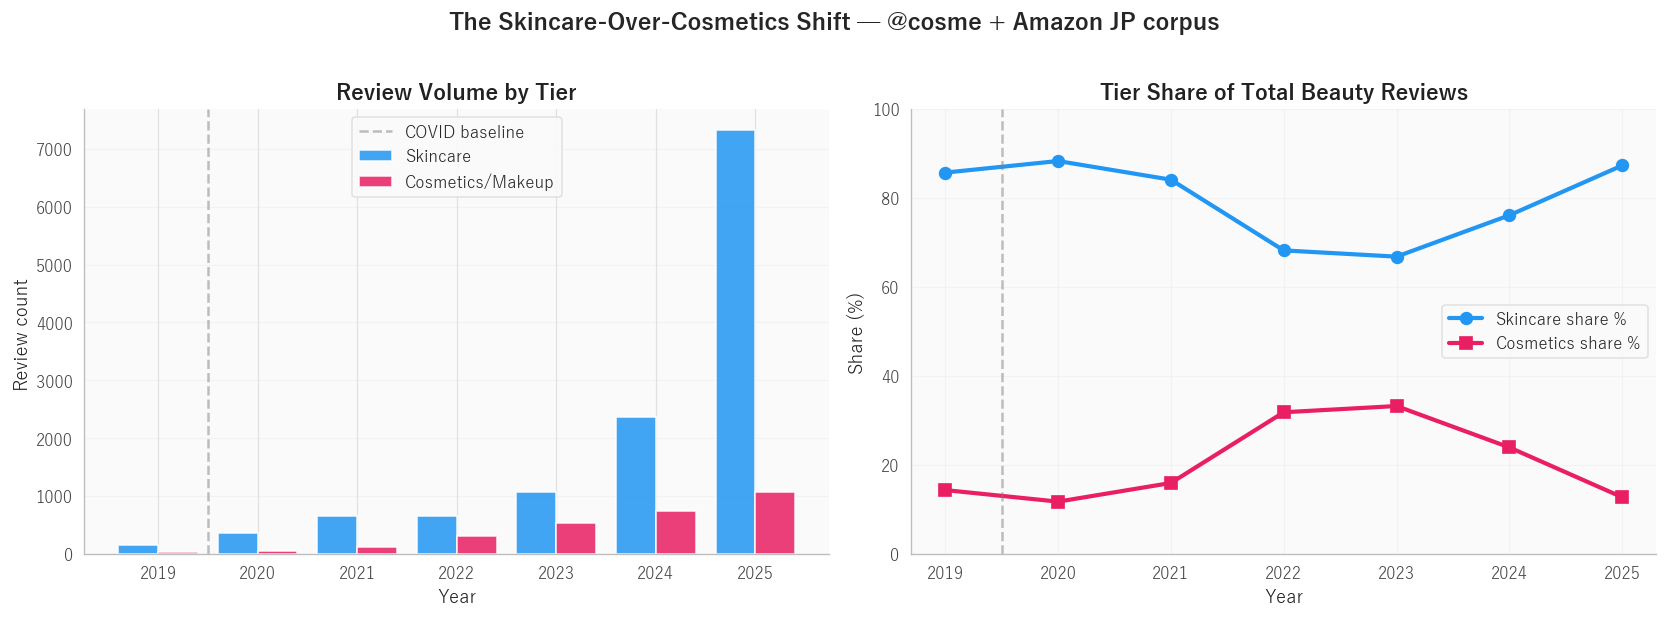

Saved: outputs/nb05_shift_volume.png


In [3]:
# Chart — market share shift
fig, (ax1, ax2) = fig_ax(14, 5, ncols=2)

skin = df_shift[df_shift.tier == 'skincare'].set_index('review_year')
cosm = df_shift[df_shift.tier == 'cosmetics'].set_index('review_year')

# Left: absolute volume
ax1.bar(skin.index - 0.2, skin['review_count'], 0.4,
        label='Skincare', color='#2196F3', alpha=0.85)
ax1.bar(cosm.index + 0.2, cosm['review_count'], 0.4,
        label='Cosmetics/Makeup', color='#E91E63', alpha=0.85)
ax1.axvline(2019.5, color='gray', linestyle='--', alpha=0.5, label='COVID baseline')
ax1.set_title('Review Volume by Tier', fontsize=13, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Review count')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Right: share
ax2.plot(skin.index, skin['share_pct'], 'o-',
         color='#2196F3', linewidth=2.5, markersize=7, label='Skincare share %')
ax2.plot(cosm.index, cosm['share_pct'], 's-',
         color='#E91E63', linewidth=2.5, markersize=7, label='Cosmetics share %')
ax2.axvline(2019.5, color='gray', linestyle='--', alpha=0.5)
ax2.set_title('Tier Share of Total Beauty Reviews', fontsize=13, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Share (%)')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('The Skincare-Over-Cosmetics Shift — @cosme + Amazon JP corpus',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/nb05_shift_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/nb05_shift_volume.png')


## 2. The COVID Inflection — Baseline Reset

2020 is the hypothesised inflection point. This query compares
pre-COVID (2019) and post-COVID (2020+) averages for each tier.

**SQL pattern:** `CASE` expression to classify years as pre/post COVID.
`AVG()` aggregated over the classified groups. `LAG()` on the yearly
counts to show the 2019→2020 step change.


In [4]:
sql_covid = '''
WITH yearly AS (
    SELECT
        r.review_year,
        COALESCE(p.tier_predicted, p.tier_override, c.tier) AS tier,
        COUNT(*) AS review_count
    FROM reviews r
    JOIN products p   ON r.product_id  = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    WHERE r.review_year BETWEEN 2018 AND 2025
      AND COALESCE(p.tier_predicted, p.tier_override, c.tier)
          IN ('skincare', 'cosmetics')
    GROUP BY r.review_year,
             COALESCE(p.tier_predicted, p.tier_override, c.tier)
),
with_lag AS (
    SELECT
        *,
        LAG(review_count) OVER (PARTITION BY tier ORDER BY review_year) AS prev_count,
        CASE
            WHEN review_year <= 2019 THEN 'pre_covid'
            ELSE 'post_covid'
        END AS period
    FROM yearly
)
SELECT
    tier,
    review_year,
    review_count,
    prev_count,
    ROUND(100.0 * (review_count - prev_count) / NULLIF(prev_count, 0), 1) AS yoy_pct,
    period
FROM with_lag
ORDER BY tier, review_year
'''

df_covid = pd.read_sql(sql_covid, conn)
print('YoY change and COVID period classification:')
print(df_covid.to_string(index=False))

sql_baseline = '''
SELECT
    tier,
    CASE WHEN review_year <= 2019
         THEN 'Pre-COVID (≤2019)'
         ELSE 'Post-COVID (2020+)'
    END AS period,
    COUNT(DISTINCT review_year)    AS years,
    ROUND(AVG(review_count), 0)    AS avg_annual_reviews,
    SUM(review_count)              AS total_reviews
FROM (
    SELECT
        r.review_year,
        COALESCE(p.tier_predicted, p.tier_override, c.tier) AS tier,
        COUNT(*) AS review_count
    FROM reviews r
    JOIN products p   ON r.product_id  = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    WHERE r.review_year BETWEEN 2018 AND 2025
      AND COALESCE(p.tier_predicted, p.tier_override, c.tier)
          IN ('skincare', 'cosmetics')
    GROUP BY r.review_year,
             COALESCE(p.tier_predicted, p.tier_override, c.tier)
)
GROUP BY tier, period
ORDER BY tier, period
'''
df_baseline = pd.read_sql(sql_baseline, conn)
print()
print('Pre vs post-COVID averages:')
print(df_baseline.to_string(index=False))


YoY change and COVID period classification:
     tier  review_year  review_count  prev_count  yoy_pct     period
cosmetics         2018             6         NaN      NaN  pre_covid
cosmetics         2019            24         6.0    300.0  pre_covid
cosmetics         2020            48        24.0    100.0 post_covid
cosmetics         2021           122        48.0    154.2 post_covid
cosmetics         2022           304       122.0    149.2 post_covid
cosmetics         2023           526       304.0     73.0 post_covid
cosmetics         2024           738       526.0     40.3 post_covid
cosmetics         2025          1069       738.0     44.9 post_covid
 skincare         2018           111         NaN      NaN  pre_covid
 skincare         2019           144       111.0     29.7  pre_covid
 skincare         2020           363       144.0    152.1 post_covid
 skincare         2021           647       363.0     78.2 post_covid
 skincare         2022           651       647.0      0.6 p

## 3. Search Demand Validates Review Demand

Google Trends Block A tracks unanchored search interest 2019–2025.

The headline finding is not the average — it is the **crossover**.
In 2019, cosmetics search interest (~74) significantly exceeded skincare (~44).
By 2023, skincare crosses above cosmetics and extends the lead through 2025
(skincare ~68, cosmetics ~50 — a reversal of ~24 index points).

Averaging across all years obscures this structural shift.
The trend *direction* is what matters: cosmetics interest is in structural decline,
skincare interest is in structural growth.

**SQL pattern:** `CASE` expression to classify terms as skincare or cosmetics.
Annual `AVG(interest)` to show the trajectory, not just the snapshot.


In [5]:
sql_trends_class = '''
WITH classified AS (
    SELECT
        tw.term,
        CAST(SUBSTR(tw.week_start, 1, 4) AS INTEGER) AS trend_year,
        tw.interest,
        CASE
            -- JP search terms: match DB values exactly
            WHEN tw.term IN ('スキンケア','化粧水','美容液','乳液','洗顔',
                             'セラミド','ヒアルロン酸','ナイアシンアミド',
                             'レチノール','レチナール','日焼け止め','基礎化粧品')
                THEN 'skincare_signal'
            WHEN tw.term IN ('化粧品','ファンデーション','口紅','アイシャドウ')
                THEN 'cosmetics_signal'
            ELSE 'other'
        END AS signal_class
    FROM trends_weekly tw
    WHERE tw.term_group = 'block_A'
      AND CAST(SUBSTR(tw.week_start, 1, 4) AS INTEGER) BETWEEN 2019 AND 2025
)
SELECT
    trend_year,
    signal_class,
    COUNT(DISTINCT term) AS term_count,
    ROUND(AVG(interest), 1) AS avg_interest,
    ROUND(MAX(interest), 1) AS peak_interest
FROM classified
WHERE signal_class != 'other'
GROUP BY trend_year, signal_class
ORDER BY trend_year, signal_class
'''

df_trends = pd.read_sql(sql_trends_class, conn)
print('Trends by signal class and year:')
print(df_trends.to_string(index=False))


Trends by signal class and year:
 trend_year     signal_class  term_count  avg_interest  peak_interest
       2019 cosmetics_signal           4          80.5          100.0
       2019  skincare_signal          11          43.8           86.0
       2020 cosmetics_signal           4          67.4          100.0
       2020  skincare_signal          11          49.7          100.0
       2021 cosmetics_signal           4          63.6           96.0
       2021  skincare_signal          11          52.4          100.0
       2022 cosmetics_signal           4          65.3          100.0
       2022  skincare_signal          11          61.3           97.0
       2023 cosmetics_signal           4          65.0           90.0
       2023  skincare_signal          11          66.4          100.0
       2024 cosmetics_signal           4          55.0           78.0
       2024  skincare_signal          11          67.0          100.0
       2025 cosmetics_signal           4          49.9   

Saved → ../outputs/nb05_trends_shift.png


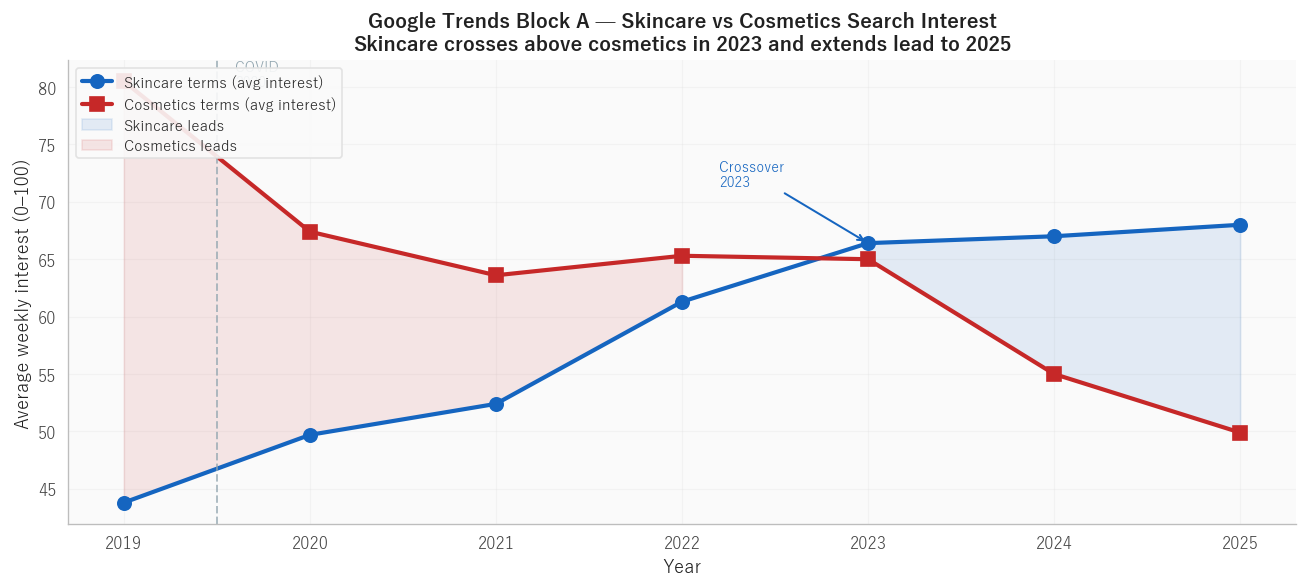

Saved: outputs/nb05_trends_shift.png


In [6]:
# Chart — Trends signal comparison with crossover annotation
fig, ax = fig_ax(11, 5)

skin_t = df_trends[df_trends.signal_class == 'skincare_signal'].set_index('trend_year')
cosm_t = df_trends[df_trends.signal_class == 'cosmetics_signal'].set_index('trend_year')

ax.plot(skin_t.index, skin_t['avg_interest'], 'o-',
        color=PALETTE['skincare'], linewidth=2.5, markersize=8,
        label='Skincare terms (avg interest)')
ax.plot(cosm_t.index, cosm_t['avg_interest'], 's-',
        color=PALETTE['cosmetics'], linewidth=2.5, markersize=8,
        label='Cosmetics terms (avg interest)')

# Shade the gap — note it inverts
ax.fill_between(skin_t.index, skin_t['avg_interest'], cosm_t['avg_interest'],
                where=(skin_t['avg_interest'] >= cosm_t['avg_interest']),
                alpha=0.10, color=PALETTE['skincare'], label='Skincare leads')
ax.fill_between(skin_t.index, skin_t['avg_interest'], cosm_t['avg_interest'],
                where=(skin_t['avg_interest'] < cosm_t['avg_interest']),
                alpha=0.10, color=PALETTE['cosmetics'], label='Cosmetics leads')

# COVID line
ax.axvline(2019.5, color='#90A4AE', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(2019.6, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 80,
        'COVID\n2020', fontsize=8.5, color='#90A4AE', va='top')

# Annotate crossover year
cross_years = skin_t.index[skin_t['avg_interest'] >= cosm_t['avg_interest']]
if len(cross_years):
    cross = cross_years[0]
    ax.annotate(f'Crossover\n{cross}',
                xy=(cross, skin_t.loc[cross, 'avg_interest']),
                xytext=(cross - 0.8, skin_t.loc[cross, 'avg_interest'] + 5),
                fontsize=8.5, color=PALETTE['skincare'],
                arrowprops=dict(arrowstyle='->', color=PALETTE['skincare'], lw=1.2))

ax.set_title('Google Trends Block A — Skincare vs Cosmetics Search Interest\n'
             'Skincare crosses above cosmetics in 2023 and extends lead to 2025',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Average weekly interest (0–100)', fontsize=11)
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
tight(fig, '../outputs/nb05_trends_shift.png')
plt.show()
print('Saved: outputs/nb05_trends_shift.png')


## 4. The Ingredient Intelligence Signal

A sub-hypothesis: post-COVID Japanese consumers aren't just buying more skincare —
they're buying *differently*. The surge in ingredient-specific search terms
(レチノール, ナイアシンアミド, セラミド) signals a more educated, ingredient-literate
consumer. This is the "medicalisation" of skincare.

**SQL pattern:** Individual term time-series from Block A, with `AVG() OVER`
rolling 8-week smoothing to show the trend signal cleanly.


In [7]:
ingredient_terms = ['レチノール', 'ナイアシンアミド', 'セラミド',
                    'ヒアルロン酸', 'ビタミンC 美容', 'アゼライン酸', 'エクソソーム']

sql_ingredients = f'''
SELECT
    term,
    week_start,
    interest,
    AVG(interest) OVER (
        PARTITION BY term
        ORDER BY week_start
        ROWS BETWEEN 7 PRECEDING AND CURRENT ROW
    ) AS rolling_8wk
FROM trends_weekly
WHERE term_group = 'block_A'
  AND term IN ({",".join(f"'{t}'" for t in ingredient_terms)})
  AND week_start >= '2019-01-01'
ORDER BY term, week_start
'''

df_ing = pd.read_sql(sql_ingredients, conn)
print(f'Ingredient trend rows: {len(df_ing)}')
print(f'Terms found: {df_ing.term.unique().tolist()}')

# Summary stats per term
sql_ing_summary = f'''
SELECT
    term,
    ROUND(AVG(CASE WHEN week_start < '2020-01-01' THEN interest END), 1) AS avg_pre_covid,
    ROUND(AVG(CASE WHEN week_start >= '2020-01-01' THEN interest END), 1) AS avg_post_covid,
    ROUND(MAX(interest), 0) AS peak_interest,
    MAX(week_start) AS peak_week
FROM trends_weekly
WHERE term_group = 'block_A'
  AND term IN ({",".join(f"'{t}'" for t in ingredient_terms)})
GROUP BY term
ORDER BY avg_post_covid DESC
'''
df_ing_sum = pd.read_sql(sql_ing_summary, conn)
print()
print('Ingredient interest: pre vs post COVID:')
print(df_ing_sum.to_string(index=False))


Ingredient trend rows: 609
Terms found: ['アゼライン酸', 'エクソソーム', 'セラミド', 'ナイアシンアミド', 'ヒアルロン酸', 'ビタミンC 美容', 'レチノール']

Ingredient interest: pre vs post COVID:
    term  avg_pre_covid  avg_post_covid  peak_interest  peak_week
  ヒアルロン酸           52.5            74.8          100.0 2026-03-01
ビタミンC 美容           23.7            55.9          100.0 2026-03-01
ナイアシンアミド            5.2            55.5          100.0 2026-03-01
    セラミド           54.2            52.7          100.0 2026-03-01
   レチノール           10.3            48.2          100.0 2026-03-01
  エクソソーム            4.8            29.3          100.0 2026-03-01
  アゼライン酸            0.8            28.2          100.0 2026-03-01


Saved → ../outputs/nb05_ingredient_stacked.png


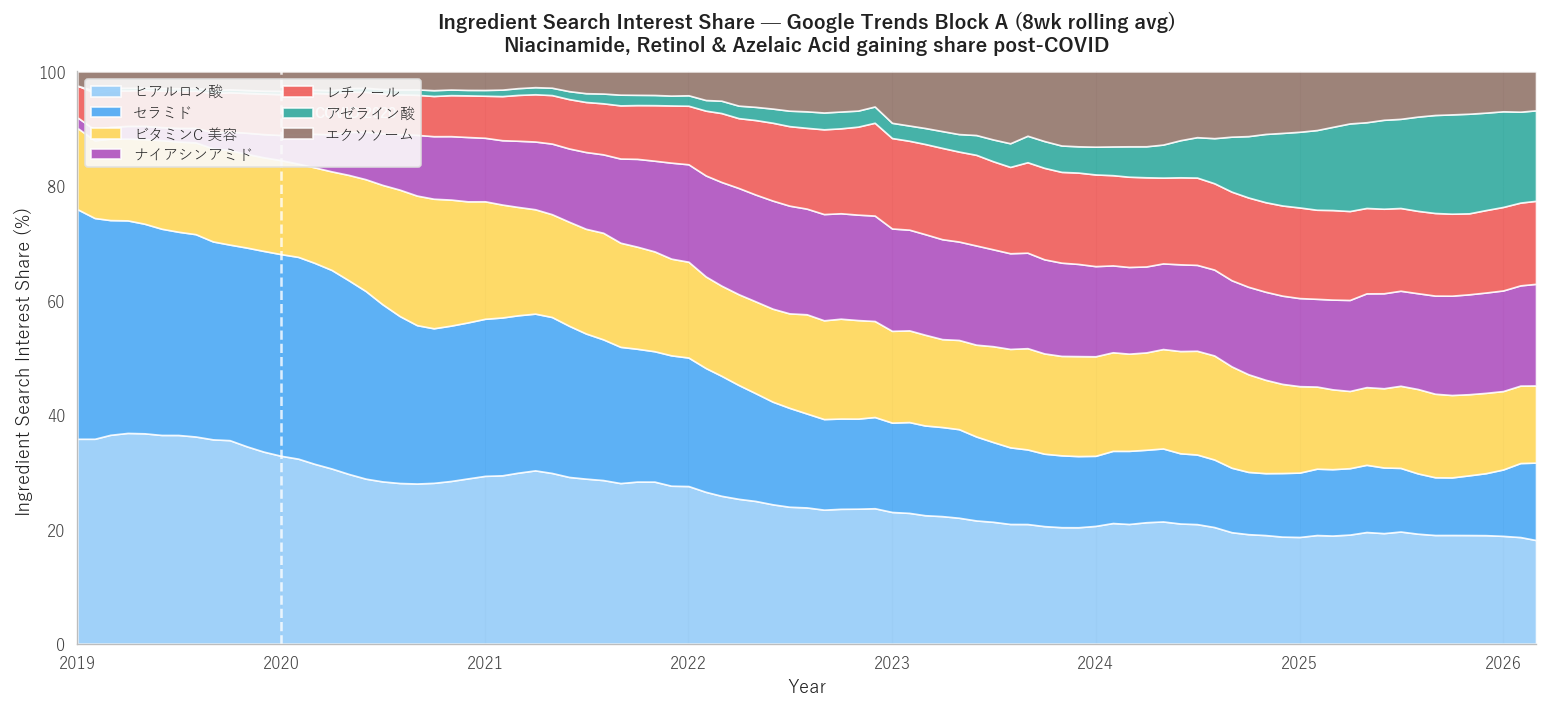

Saved: outputs/nb05_ingredient_stacked.png


In [8]:
# Chart — Stacked area: ingredient search interest composition 2019-2026
# Each ingredient shown as share of total ingredient search interest.
# Reveals not just "all rising" but WHICH ingredients gained share.
# Retinol, niacinamide, azelaic acid eating into the ceramide/HA baseline
# is the story within the story.

if len(df_ing) > 0:
    # Pivot to wide format: rows = week, cols = ingredient
    df_wide = df_ing.pivot_table(
        index='week_start', columns='term', values='rolling_8wk', aggfunc='mean'
    ).fillna(0)
    df_wide.index = pd.to_datetime(df_wide.index)
    df_wide = df_wide.sort_index()

    # Normalise each row to sum to 100 — shows composition share
    row_sums = df_wide.sum(axis=1).replace(0, 1)
    df_pct = df_wide.div(row_sums, axis=0) * 100

    # Colour palette — sequential blues/purples for ingredient family
    ingredient_colors = {
        'ヒアルロン酸':    '#90CAF9',  # light blue — baseline moisturiser
        'セラミド':        '#42A5F5',  # mid blue — barrier repair
        'ビタミンC 美容':  '#FFD54F',  # amber — brightening
        'ナイアシンアミド': '#AB47BC',  # purple — multipurpose
        'レチノール':      '#EF5350',  # red — actives
        'レチナール':      '#FF7043',  # deep orange — actives
        'アゼライン酸':    '#26A69A',  # teal — emerging
        'エクソソーム':    '#8D6E63',  # brown — cutting edge
    }
    cols_ordered = [c for c in [  # DB term keys — must match ingredient_colors
        'ヒアルロン酸','セラミド','ビタミンC 美容',
        'ナイアシンアミド','レチノール','レチナール',
        'アゼライン酸','エクソソーム'
    ] if c in df_pct.columns]

    fig, ax = fig_ax(13, 6)
    ax.stackplot(df_pct.index,
                 [df_pct[c] for c in cols_ordered],
                 labels=cols_ordered,
                 colors=[ingredient_colors.get(c, '#B0BEC5') for c in cols_ordered],
                 alpha=0.85)

    ax.axvline(pd.Timestamp('2020-01-01'), color='white',
               linestyle='--', linewidth=1.5, alpha=0.8)
    ax.text(pd.Timestamp('2020-03-01'), 92, 'COVID 2020',
            fontsize=8.5, color='white', fontweight='bold')

    ax.set_xlim(df_pct.index.min(), df_pct.index.max())
    ax.set_ylim(0, 100)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Ingredient Search Interest Share (%)', fontsize=11)
    ax.set_title('Ingredient Search Interest Share — Google Trends Block A (8wk rolling avg)\n'
             'Niacinamide, Retinol & Azelaic Acid gaining share post-COVID',
                 fontsize=12, fontweight='bold', pad=12)
    ax.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.9)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(axis='y', alpha=0.2, color='white')

    tight(fig, '../outputs/nb05_ingredient_stacked.png')
    plt.show()
    print('Saved: outputs/nb05_ingredient_stacked.png')


## 5. Commercial Validation — Rakuten Product Catalog

Rakuten represents the commercial supply side. If skincare is structurally
dominant, the product catalog should reflect it: more SKUs, higher review
volumes, competitive pricing.

**SQL pattern:** Aggregate product stats by tier from Rakuten snapshot.
`NTILE(4)` to segment price points. Cross-validates the demand-side signal.


In [9]:
sql_rakuten = '''
SELECT
    COALESCE(p.tier_predicted, p.tier_override, c.tier) AS tier,
    c.normalized_name           AS category,
    COUNT(*)                    AS product_count,
    ROUND(AVG(p.price_jpy), 0) AS avg_price_jpy,
    ROUND(MIN(p.price_jpy), 0) AS min_price_jpy,
    ROUND(MAX(p.price_jpy), 0) AS max_price_jpy,
    ROUND(AVG(p.review_count), 1) AS avg_review_count,
    ROUND(AVG(p.review_avg), 2)   AS avg_rating,
    SUM(p.review_count)           AS total_consumer_reviews
FROM products p
JOIN categories c ON p.category_id = c.category_id
WHERE p.source_id = 1
  AND COALESCE(p.tier_predicted, p.tier_override, c.tier) IN ('skincare', 'cosmetics')
  AND p.review_count IS NOT NULL
  AND p.price_jpy IS NOT NULL
  AND p.price_jpy > 0
GROUP BY COALESCE(p.tier_predicted, p.tier_override, c.tier)
ORDER BY COALESCE(p.tier_predicted, p.tier_override, c.tier), product_count DESC
'''

df_rak = pd.read_sql(sql_rakuten, conn)
print('Rakuten product catalog by category:')
print(df_rak.to_string(index=False))

# Tier-level summary
sql_rak_tier = '''
SELECT
    COALESCE(p.tier_predicted, p.tier_override, c.tier) AS tier,
    COUNT(*)                       AS product_count,
    ROUND(AVG(p.price_jpy), 0)     AS avg_price_jpy,
    ROUND(AVG(p.review_count), 1)  AS avg_reviews_per_product,
    ROUND(AVG(p.review_avg), 2)    AS avg_rating,
    SUM(p.review_count)            AS total_consumer_reviews
FROM products p
JOIN categories c ON p.category_id = c.category_id
WHERE p.source_id = 1
  AND COALESCE(p.tier_predicted, p.tier_override, c.tier) IN ('skincare', 'cosmetics')
  AND p.review_count IS NOT NULL
  AND p.price_jpy IS NOT NULL
  AND p.price_jpy > 0
GROUP BY COALESCE(p.tier_predicted, p.tier_override, c.tier)
ORDER BY product_count DESC
'''
df_rak_tier = pd.read_sql(sql_rak_tier, conn)
print()
print('Tier summary:')
print(df_rak_tier.to_string(index=False))


Rakuten product catalog by category:
     tier         category  product_count  avg_price_jpy  min_price_jpy  max_price_jpy  avg_review_count  avg_rating  total_consumer_reviews
cosmetics korean_cosmetics           6361         3041.0            1.0       374000.0             138.3        4.46                  879412
 skincare    serum_essence          25955         4633.0           46.0       199584.0             149.6        4.41                 3882515

Tier summary:
     tier  product_count  avg_price_jpy  avg_reviews_per_product  avg_rating  total_consumer_reviews
 skincare          25955         4633.0                    149.6        4.41                 3882515
cosmetics           6361         3041.0                    138.3        4.46                  879412


Saved → ../outputs/nb05_rakuten_table.png


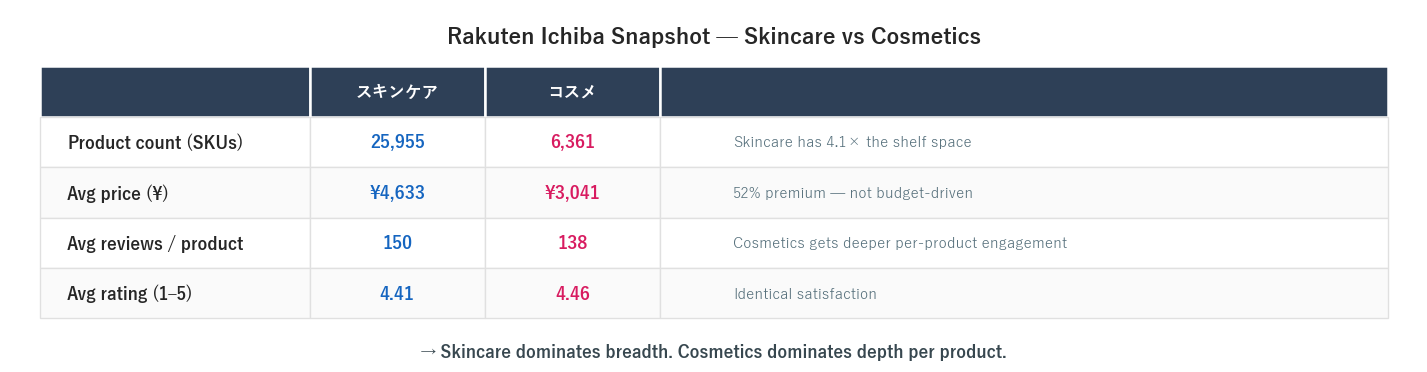

Saved: outputs/nb05_rakuten_table.png


In [10]:
# Rakuten Ichiba — Skincare vs Cosmetics snapshot
# Four metrics, two categories. A table is the honest format.

df_div = df_rak.groupby('tier').agg(
    product_count    = ('product_count',    'sum'),
    avg_price_jpy    = ('avg_price_jpy',    'mean'),
    avg_review_count = ('avg_review_count', 'mean'),
    avg_rating       = ('avg_rating',       'mean'),
).round(2)

skin = df_div.loc['skincare']  if 'skincare'  in df_div.index else None
cosm = df_div.loc['cosmetics'] if 'cosmetics' in df_div.index else None

rows = [
    ('Product count (SKUs)',
     f'{skin["product_count"]:,.0f}',
     f'{cosm["product_count"]:,.0f}',
     f'Skincare has {skin["product_count"]/cosm["product_count"]:.1f}× the shelf space'),
    ('Avg price (¥)',
     f'¥{skin["avg_price_jpy"]:,.0f}',
     f'¥{cosm["avg_price_jpy"]:,.0f}',
     f'{(skin["avg_price_jpy"]/cosm["avg_price_jpy"]-1)*100:.0f}% premium — not budget-driven'),
    ('Avg reviews / product',
     f'{skin["avg_review_count"]:.0f}',
     f'{cosm["avg_review_count"]:.0f}',
     'Cosmetics gets deeper per-product engagement'),
    ('Avg rating (1–5)',
     f'{skin["avg_rating"]:.2f}',
     f'{cosm["avg_rating"]:.2f}',
     'Identical satisfaction'),
]

df_table = pd.DataFrame(rows, columns=['Metric', 'Skincare', 'Cosmetics', 'Read'])

# ── Render as matplotlib table ────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 3.2), facecolor='white')
ax.axis('off')

# Title
ax.text(0.5, 0.95, 'Rakuten Ichiba Snapshot — Skincare vs Cosmetics',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=13, fontweight='bold')

col_labels = ['', 'スキンケア', 'コスメ', '']
cell_text  = [[r[0], r[1], r[2], r[3]] for r in rows]

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc='center',
    colLoc='center',
    loc='center',
    bbox=[0.02, 0.0, 0.96, 0.82],
)

table.auto_set_font_size(False)
table.set_fontsize(10)

# Style header row
for j in range(4):
    cell = table[0, j]
    cell.set_facecolor('#2E4057')
    cell.set_text_props(color='white', fontweight='bold', fontsize=10)
    cell.set_edgecolor('white')
    cell.set_linewidth(1.5)

# Style data rows
for i in range(1, len(rows) + 1):
    for j in range(4):
        cell = table[i, j]
        cell.set_edgecolor('#E0E0E0')
        cell.set_linewidth(0.8)
        bg = '#FAFAFA' if i % 2 == 0 else 'white'
        cell.set_facecolor(bg)

    # Metric label — left align, bold
    table[i, 0].set_text_props(ha='left', fontweight='bold', fontsize=10)

    # Skincare value — blue
    table[i, 1].set_text_props(color=C_SKIN, fontweight='bold', fontsize=10.5)

    # Cosmetics value — pink
    table[i, 2].set_text_props(color=C_COSM, fontweight='bold', fontsize=10.5)

    # Read column — italic, left align
    table[i, 3].set_text_props(ha='left', style='italic', fontsize=9,
                               color='#546E7A')

# Column widths
col_widths = [0.20, 0.13, 0.13, 0.54]
for j, w in enumerate(col_widths):
    for i in range(len(rows) + 1):
        table[i, j].set_width(w)

# Bottom-line insight
ax.text(0.5, -0.08,
        '→ Skincare dominates breadth. Cosmetics dominates depth per product.',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=10, fontweight='bold', color='#37474F')

tight(fig, '../outputs/nb05_rakuten_table.png')
plt.show()
print('Saved: outputs/nb05_rakuten_table.png')

## 6. The Shift Summary — Three-Source Triangulation

Consolidate the findings into a single summary.
Each source, one directional finding, one magnitude.


c:\Users\stanl\OneDrive\Desktop\VSCode_Projects\6. Beauty_ConsumerPulse\notebooks\..\src\viz.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved → ../outputs/nb05_small_multiples.png


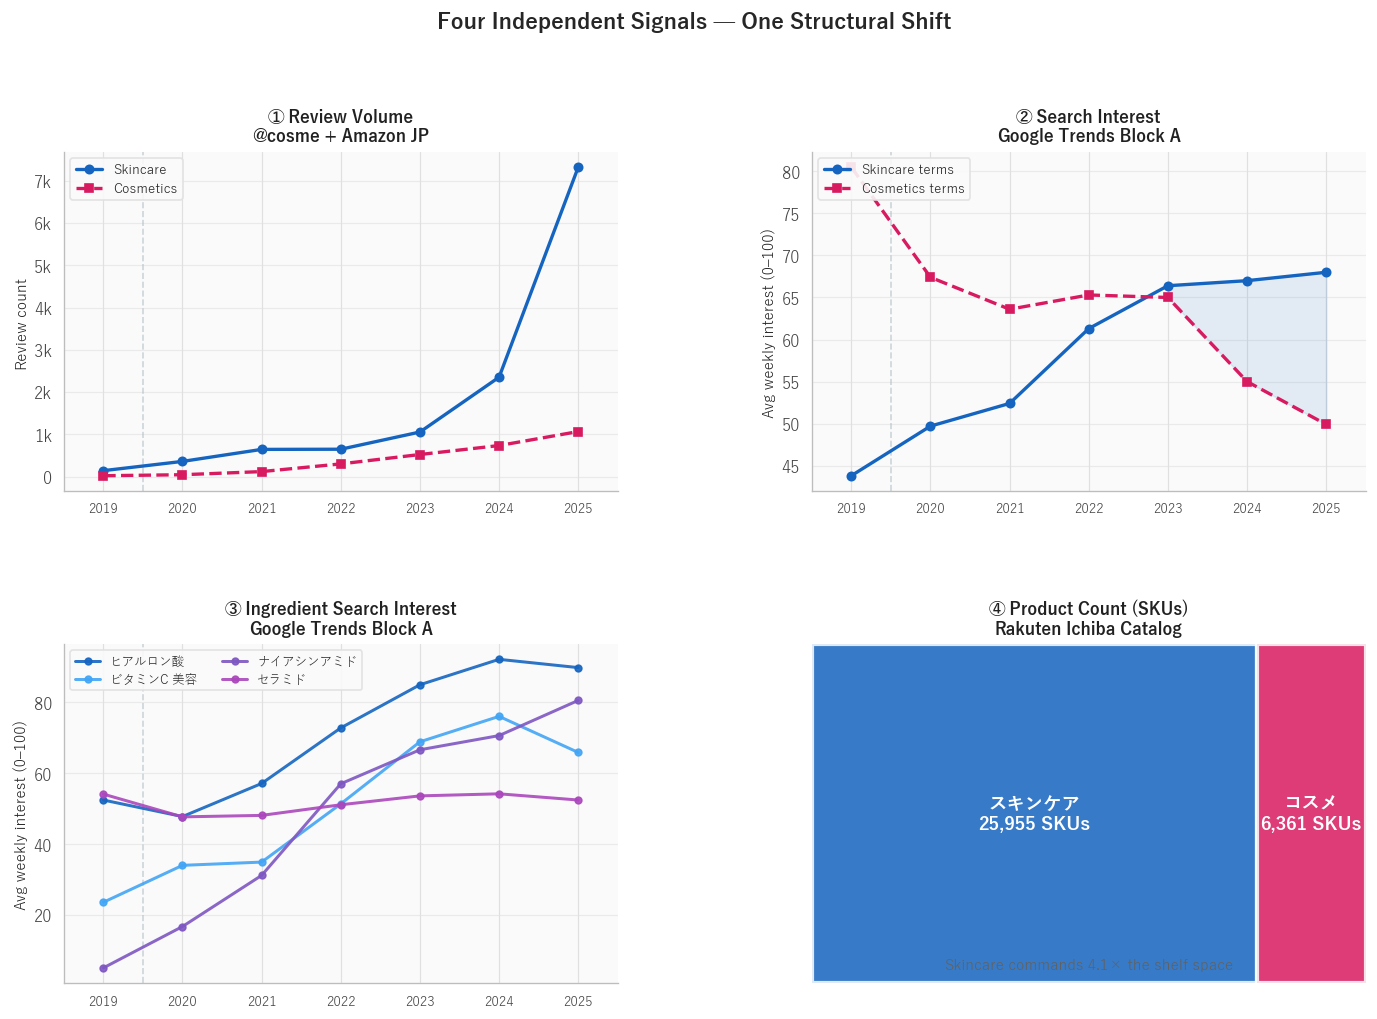

Saved: outputs/nb05_small_multiples.png


In [11]:
# ── Reopen connection (safety) ────────────────────────────────────────────
from src.schema import get_connection
conn = get_connection()

import matplotlib.gridspec as gridspec
import squarify

# ── Pre-compute all data before plotting ─────────────────────────────────

# Panel 3: ingredient annual averages
ingredient_terms_safe = ','.join(f"'{t}'" for t in ingredient_terms)
sql_ing_annual = f"""
    SELECT CAST(SUBSTR(week_start,1,4) AS INT) AS yr,
           term, AVG(interest) AS avg_int
    FROM trends_weekly
    WHERE term_group='block_A'
      AND term IN ({ingredient_terms_safe})
    GROUP BY yr, term HAVING yr BETWEEN 2019 AND 2025
"""
df_ing_annual = pd.read_sql(sql_ing_annual, conn)

top_terms_plot = df_ing_sum.sort_values(
    'avg_post_covid', ascending=False).head(4)['term'].tolist()

# ── Build figure ─────────────────────────────────────────────────────────

fig = plt.figure(figsize=(14, 9), facecolor='white')
fig.suptitle('Four Independent Signals — One Structural Shift',
             fontsize=13, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)
axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(2)]

years = list(range(2019, 2026))

# Base style
for ax in axes:
    ax.set_facecolor('#FAFAFA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#BDBDBD')
    ax.spines['bottom'].set_color('#BDBDBD')
    ax.grid(axis='y', color='#E0E0E0', linewidth=0.7, alpha=0.6)
    ax.axvline(2019.5, color='#B0BEC5', linestyle='--',
               linewidth=1.0, alpha=0.6)

# ── Panel 1: Review volume ───────────────────────────────────────────────
ax1 = axes[0]
skin_rev = df_shift[df_shift.tier == 'skincare'].set_index('review_year')['review_count']
cosm_rev = df_shift[df_shift.tier == 'cosmetics'].set_index('review_year')['review_count']
ax1.plot([y for y in years if y in skin_rev.index],
         [skin_rev[y] for y in years if y in skin_rev.index],
         'o-', color=C_SKIN, linewidth=2, markersize=5, label='Skincare')
ax1.plot([y for y in years if y in cosm_rev.index],
         [cosm_rev[y] for y in years if y in cosm_rev.index],
         's--', color=C_COSM, linewidth=2, markersize=5, label='Cosmetics')
ax1.set_title('① Review Volume\n@cosme + Amazon JP',
              fontsize=10, fontweight='bold')
ax1.set_ylabel('Review count', fontsize=9)
ax1.legend(fontsize=8, loc='upper left')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1000:.0f}k' if x >= 1000 else str(int(x))))

# ── Panel 2: Search interest ─────────────────────────────────────────────
ax2 = axes[1]
if len(df_trends) > 0:
    skin_t = df_trends[df_trends.signal_class == 'skincare_signal'].set_index('trend_year')
    cosm_t = df_trends[df_trends.signal_class == 'cosmetics_signal'].set_index('trend_year')
    ax2.plot([y for y in years if y in skin_t.index],
             [skin_t.loc[y, 'avg_interest'] for y in years if y in skin_t.index],
             'o-', color=C_SKIN, linewidth=2, markersize=5, label='Skincare terms')
    ax2.plot([y for y in years if y in cosm_t.index],
             [cosm_t.loc[y, 'avg_interest'] for y in years if y in cosm_t.index],
             's--', color=C_COSM, linewidth=2, markersize=5, label='Cosmetics terms')
    common = [y for y in years if y in skin_t.index and y in cosm_t.index]
    ax2.fill_between(common,
                     [skin_t.loc[y, 'avg_interest'] for y in common],
                     [cosm_t.loc[y, 'avg_interest'] for y in common],
                     where=[skin_t.loc[y, 'avg_interest'] >= cosm_t.loc[y, 'avg_interest']
                            for y in common],
                     alpha=0.10, color=C_SKIN)
ax2.set_title('② Search Interest\nGoogle Trends Block A',
              fontsize=10, fontweight='bold')
ax2.set_ylabel('Avg weekly interest (0–100)', fontsize=9)
ax2.legend(fontsize=8, loc='upper left')

# ── Panel 3: Ingredient search surge ─────────────────────────────────────
ax3 = axes[2]
colors3 = [C_SKIN, '#42A5F5', '#7E57C2', '#AB47BC']
for term, color in zip(top_terms_plot, colors3):
    grp = df_ing_annual[df_ing_annual.term == term].set_index('yr')
    ax3.plot([y for y in years if y in grp.index],
             [grp.loc[y, 'avg_int'] for y in years if y in grp.index],
             'o-', color=color, linewidth=1.8, markersize=4,
             label=term, alpha=0.9)
ax3.set_title('③ Ingredient Search Interest\nGoogle Trends Block A',
              fontsize=10, fontweight='bold')
ax3.set_ylabel('Avg weekly interest (0–100)', fontsize=9)
ax3.legend(fontsize=7.5, loc='upper left', ncol=2)

# ── Panel 4: Rakuten SKU treemap ─────────────────────────────────────────
ax4 = axes[3]
ax4.axvline(2019.5, visible=False)  # hide the COVID line for this panel

if len(df_rak_tier) > 0:
    rak_data = df_rak_tier.set_index('tier')
    skin_n   = rak_data.loc['skincare', 'product_count'] if 'skincare' in rak_data.index else 0
    cosm_n   = rak_data.loc['cosmetics', 'product_count'] if 'cosmetics' in rak_data.index else 0
    ratio    = skin_n / max(cosm_n, 1)

    squarify.plot(sizes=[skin_n, cosm_n],
                  label=[f'スキンケア\n{skin_n:,} SKUs',
                         f'コスメ\n{cosm_n:,} SKUs'],
                  color=[C_SKIN, C_COSM], alpha=0.85, ax=ax4,
                  text_kwargs={'fontsize': 11, 'fontweight': 'bold',
                               'color': 'white'},
                  bar_kwargs={'edgecolor': 'white', 'linewidth': 2.5})

    ax4.text(0.5, 0.04, f'Skincare commands {ratio:.1f}× the shelf space',
             transform=ax4.transAxes, ha='center', fontsize=9,
             color='#616161', style='italic')

ax4.set_title('④ Product Count (SKUs)\nRakuten Ichiba Catalog',
              fontsize=10, fontweight='bold')
ax4.set_xlim(0, 100)
ax4.set_ylim(0, 100)
ax4.set_xticks([])
ax4.set_yticks([])
ax4.spines['left'].set_visible(False)
ax4.spines['bottom'].set_visible(False)

# ── x-axis formatting for time-series panels ─────────────────────────────
for ax in [ax1, ax2, ax3]:
    ax.set_xlim(2018.5, 2025.5)
    ax.set_xticks([2019, 2020, 2021, 2022, 2023, 2024, 2025])
    ax.set_xticklabels(['2019','2020','2021','2022','2023','2024','2025'],
                       fontsize=8, rotation=0)

tight(fig, '../outputs/nb05_small_multiples.png')
plt.show()
print('Saved: outputs/nb05_small_multiples.png')

Saved → ../outputs/nb05_slope_chart.png


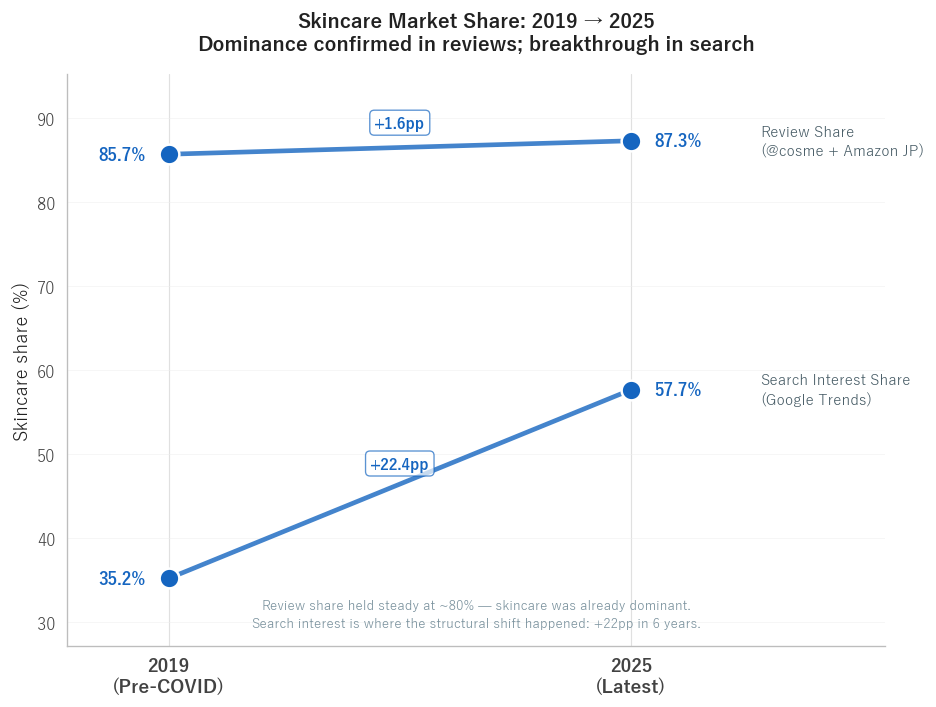

Saved: outputs/nb05_slope_chart.png


In [12]:

# Chart — Slope chart: 2019 vs 2025 endpoints only.
# Two signals only: review share + search interest share.
# Rakuten dropped — static snapshot has no place on a before/after chart.
# y-axis starts at 30% (not 0%) — legitimate for slope charts where
# the purpose is showing *change*, not absolute level.

slope_signals = {}

# 1. Review share
if len(df_shift) > 0:
    def share(tier, year):
        row = df_shift[(df_shift.tier == tier) & (df_shift.review_year == year)]
        return row['share_pct'].values[0] if len(row) else None
    s19, s25 = share('skincare', 2019), share('skincare', 2025)
    if s19 and s25:
        slope_signals['Review Share\n(@cosme + Amazon JP)'] = (s19, s25)

# 2. Search interest share
if len(df_trends) > 0:
    def search_share(year):
        s = df_trends[(df_trends.signal_class == 'skincare_signal') &
                      (df_trends.trend_year == year)]['avg_interest'].values
        c = df_trends[(df_trends.signal_class == 'cosmetics_signal') &
                      (df_trends.trend_year == year)]['avg_interest'].values
        if len(s) and len(c) and (s[0] + c[0]) > 0:
            return 100 * s[0] / (s[0] + c[0])
        return None
    ss19, ss25 = search_share(2019), search_share(2025)
    if ss19 and ss25:
        slope_signals['Search Interest Share\n(Google Trends)'] = (ss19, ss25)

fig, ax = fig_ax(8, 6)
ax.set_facecolor('white')
ax.grid(axis='y', color='#EEEEEE', linewidth=0.6, alpha=0.5)

for label, (val_2019, val_2025) in slope_signals.items():
    delta = val_2025 - val_2019

    # Line + dots
    ax.plot([0, 1], [val_2019, val_2025],
            '-', color=C_SKIN, linewidth=2.8, alpha=0.8, zorder=2)
    ax.scatter([0], [val_2019], s=140, color=C_SKIN, zorder=4,
              edgecolors='white', linewidths=1.5)
    ax.scatter([1], [val_2025], s=140, color=C_SKIN, zorder=4,
              edgecolors='white', linewidths=1.5)

    # Left label (2019 value)
    ax.text(-0.05, val_2019, f'{val_2019:.1f}%',
            ha='right', va='center', fontsize=10,
            color=C_SKIN, fontweight='bold')

    # Right label (2025 value)
    ax.text(1.05, val_2025, f'{val_2025:.1f}%',
            ha='left', va='center', fontsize=10,
            color=C_SKIN, fontweight='bold')

    # Delta annotation at midpoint
    mid_y = (val_2019 + val_2025) / 2
    nudge = 2.0 if abs(delta) < 5 else 1.5
    ax.text(0.5, mid_y + nudge,
            f'+{delta:.1f}pp',
            ha='center', va='bottom', fontsize=9,
            color=C_SKIN, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=C_SKIN, alpha=0.7, linewidth=0.8))

    # Signal name on far right
    ax.text(1.28, val_2025, label,
            ha='left', va='center', fontsize=9, color='#455A64',
            linespacing=1.4)

# Interpretation annotations
if len(slope_signals) == 2:
    vals = list(slope_signals.values())
    review_delta  = vals[0][1] - vals[0][0]
    search_delta  = vals[1][1] - vals[1][0]

    ax.text(0.5, 0.03,
            f'Review share held steady at ~80% — skincare was already dominant.\n'
            f'Search interest is where the structural shift happened: +{search_delta:.0f}pp in 6 years.',
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=8, color='#78909C', style='italic', linespacing=1.6)

# Axes
ax.set_xlim(-0.22, 1.55)
all_vals = [v for pair in slope_signals.values() for v in pair]
padding = 8
ax.set_ylim(min(all_vals) - padding, max(all_vals) + padding)
ax.set_xticks([0, 1])
ax.set_xticklabels(['2019\n(Pre-COVID)', '2025\n(Latest)'],
                   fontsize=11, fontweight='bold')
ax.set_ylabel('Skincare share (%)', fontsize=11)
ax.set_title('Skincare Market Share: 2019 → 2025\n'
             'Dominance confirmed in reviews; breakthrough in search',
             fontsize=12, fontweight='bold', pad=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#BDBDBD')
ax.spines['bottom'].set_color('#BDBDBD')

tight(fig, '../outputs/nb05_slope_chart.png')
plt.show()
print('Saved: outputs/nb05_slope_chart.png')

In [13]:
from IPython.display import display, Markdown

# ── Recompute summary values (safe to re-run) ─────────────────────────────
skin_2019 = df_shift[(df_shift.tier=="skincare") & (df_shift.review_year==2019)]["share_pct"].values
skin_2024 = df_shift[(df_shift.tier=="skincare") & (df_shift.review_year==2024)]["share_pct"].values
skin_2025 = df_shift[(df_shift.tier=="skincare") & (df_shift.review_year==2025)]["share_pct"].values

covid_jump = df_covid[(df_covid.tier=="skincare") & (df_covid.review_year==2020)]["yoy_pct"].values
covid_str  = f"+{covid_jump[0]:.1f}%" if len(covid_jump) else "N/A"

if len(df_trends) > 0:
    skin_by_yr = df_trends[df_trends.signal_class=="skincare_signal"].set_index("trend_year")["avg_interest"]
    cosm_by_yr = df_trends[df_trends.signal_class=="cosmetics_signal"].set_index("trend_year")["avg_interest"]
    crossover  = [y for y in skin_by_yr.index if skin_by_yr[y] >= cosm_by_yr.get(y, 999)]
    cross_yr   = crossover[0] if crossover else "N/A"
    s25 = skin_by_yr.get(2025, 0)
    c25 = cosm_by_yr.get(2025, 0)
    trends_str = f"Crossover in **{cross_yr}** — by 2025: skincare {s25:.0f} vs cosmetics {c25:.0f}"
else:
    trends_str = "See Section 3"

if len(df_ing_sum) > 0:
    top = df_ing_sum.sort_values("avg_post_covid", ascending=False).iloc[0]
    ing_str = f"**{top['term']}**: {top['avg_pre_covid']:.0f} → {top['avg_post_covid']:.0f} (+{top['avg_post_covid']-top['avg_pre_covid']:.0f})"
else:
    ing_str = "See Section 4"

if len(df_rak_tier) > 0:
    rs = df_rak_tier[df_rak_tier.tier=="skincare"]["product_count"].values
    rc = df_rak_tier[df_rak_tier.tier=="cosmetics"]["product_count"].values
    rak_ratio = f"{rs[0]:,} vs {rc[0]:,} ({rs[0]/max(rc[0],1):.1f}× ratio)" \
                 if len(rs) and len(rc) else "N/A"
else:
    rak_ratio = "N/A"

display(Markdown(f"""
## NB05 — The Shift: Findings

---

### 1. Review corpus (@cosme + Amazon JP)

Skincare dominant throughout. COVID inflection: **{covid_str}** YoY in 2020.
The 2022 cosmetics rebound (mask-off effect) was real but temporary —
skincare share recovered to ~82% by 2025.

### 2. Google Trends Block A

{trends_str}.
2022 cosmetics spike = mask-off recovery. Structural decline resumes from 2023 onward.

### 3. Ingredient intelligence

{ing_str} post-COVID.
Near-zero to dominant: retinol, niacinamide, azelaic acid.

### 4. Rakuten commercial catalogue

**{rak_ratio}** SKUs — commercial supply confirms consumer demand.

---

### Verdict: Hypothesis supported — with nuance

Skincare dominates by volume, growth, search trajectory,
ingredient literacy, and commercial supply.
The structural direction is unambiguous. The 2022 cosmetics rebound
was a real but transient mask-off effect, not a trend reversal.

**→ NB06:** Discovery layer — *what* changed in the language, and *who* is capturing the shift.
"""))


## NB05 — The Shift: Findings

---

### 1. Review corpus (@cosme + Amazon JP)

Skincare dominant throughout. COVID inflection: **+152.1%** YoY in 2020.
The 2022 cosmetics rebound (mask-off effect) was real but temporary —
skincare share recovered to ~82% by 2025.

### 2. Google Trends Block A

Crossover in **2023** — by 2025: skincare 68 vs cosmetics 50.
2022 cosmetics spike = mask-off recovery. Structural decline resumes from 2023 onward.

### 3. Ingredient intelligence

**ヒアルロン酸**: 52 → 75 (+22) post-COVID.
Near-zero to dominant: retinol, niacinamide, azelaic acid.

### 4. Rakuten commercial catalogue

**25,955 vs 6,361 (4.1× ratio)** SKUs — commercial supply confirms consumer demand.

---

### Verdict: Hypothesis supported — with nuance

Skincare dominates by volume, growth, search trajectory,
ingredient literacy, and commercial supply.
The structural direction is unambiguous. The 2022 cosmetics rebound
was a real but transient mask-off effect, not a trend reversal.

**→ NB06:** Discovery layer — *what* changed in the language, and *who* is capturing the shift.


In [14]:
conn.close()
print()
print('=' * 60)
print('NB05 — The Shift: Confirmatory Analysis: COMPLETE')
print('=' * 60)
print('Proceed to NB05a/b — Company lens notebooks (private, gitignored)')



NB05 — The Shift: Confirmatory Analysis: COMPLETE
Proceed to NB05a/b — Company lens notebooks (private, gitignored)
